# ⚽ Step 6 — World Cup 2026 Forecast (Application B)

**One project, two applications.** In the league notebooks we built Random Forest /
XGBoost / SVM to predict football and used them to *try to beat a betting market*.
Here we point the **same methodology** at a second, live decision: **forecasting the
2026 World Cup** — who reaches each knockout round, and who lifts the trophy.

The pipeline mirrors the league work:

| League project | World Cup project |
|---|---|
| club features (rolling xG/form, market odds) | **Elo** from 150 years of internationals + form |
| RF / XGBoost / SVM, time-based split | same 3 models, train/validation/test |
| probabilities → **value bets** | probabilities → **Monte Carlo of the bracket** |

> The tournament is **live** (today is during the 2026 World Cup): the group stage is
> played, so we *test* the model on real group results, then **simulate the knockout**.


## 1. Setup

In [1]:
import sys; sys.path.append("../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import worldcup as W

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Team strength — Elo from 150 years of matches

The FIFA ranking in our data stops in **2024**, so it can't rate teams for 2026.
Instead we compute **Elo** ourselves from the full international match history
(1872→today): every team's rating updates after each game (bigger wins and more
important matches move it more). Elo stays current right up to the last match played.

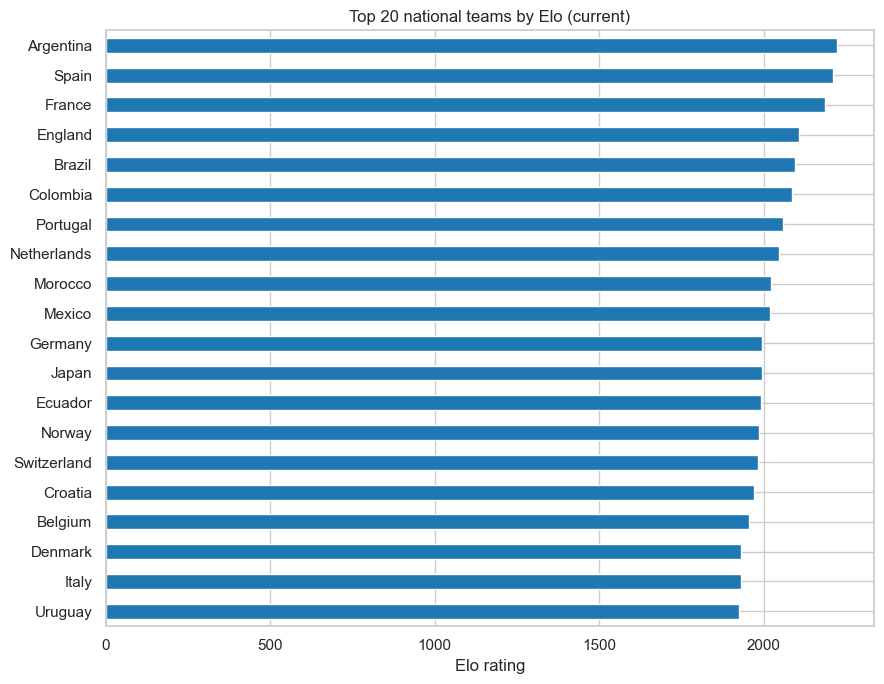

Argentina      2224.0
Spain          2211.0
France         2188.0
England        2109.0
Brazil         2095.0
Colombia       2088.0
Portugal       2060.0
Netherlands    2046.0
Morocco        2023.0
Mexico         2018.0
Germany        1995.0
Japan          1994.0
Ecuador        1994.0
Norway         1986.0
Switzerland    1982.0
Croatia        1971.0
Belgium        1957.0
Denmark        1933.0
Italy          1931.0
Uruguay        1925.0
dtype: float64

In [2]:
tbl, ratings = W.build_model_table()
top = pd.Series(ratings).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
top.iloc[::-1].plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Top 20 national teams by Elo (current)")
ax.set_xlabel("Elo rating")
plt.tight_layout(); plt.show()
top.round(0)

**Reading it:** Argentina (World Cup holders + Copa champions) and Spain (Euro 2024
winners) top the list — a sanity check that the self-computed Elo is sound, with no
hand-tuning.

## 3. Features and the modeling table

For every match we build leakage-safe, pre-match features: the **Elo difference**
(the strongest signal), each team's Elo level, recent form (last-5 points & goal
difference), and whether the venue is neutral. The target is the result (H / D / A).

In [3]:
print("table:", tbl.shape, "| features:", W.WC_FEATURES)
m = tbl[(tbl.result.notna()) & (tbl.date >= "2002-01-01")]
print("\nMean Elo difference by actual result (home minus away):")
print(m.groupby("result")["elo_diff"].mean().round(1).to_string())

table: (49493, 22) | features: ['elo_diff', 'home_elo_pre', 'away_elo_pre', 'neutral_int', 'home_form_pts', 'away_form_pts', 'home_form_gd', 'away_form_gd', 'form_pts_diff', 'form_gd_diff']

Mean Elo difference by actual result (home minus away):
result
A    -92.5
D     60.1
H    215.8


**Reading it:** Elo difference cleanly separates outcomes — home wins average a big
positive Elo edge, away wins a negative one, draws in between. Strong, honest signal.

## 4. Train / Validation / Test

Same discipline as the league project, time-ordered:

- **Train** (2002 → 2020) — the models learn
- **Validation** (2021 → June 2026) — tune / sanity-check, never touching the test
- **Test** = the **2026 group stage** (already played!) — our real-world check

We test two things on the group stage: per-match accuracy, and — the headline —
**how many of the 32 teams that actually advanced did the model get right** (2026
format: top 2 of each group + the 8 best third-placed teams).

In [4]:
train, val, test, dev = W.wc_split(tbl)
print(f"TRAIN {len(train):5d}  VAL {len(val):5d}  TEST(group stage) {len(test)}")

# train all three on pre-World-Cup data (capped so SVM stays fast)
models_dev, pipe_dev, le_dev = W.train_wc_models(dev, max_train=8000)
proba_dev = W.proba_for(models_dev, test, pipe_dev, le_dev)

ytrue = test["result"].astype(str).values
elo_pick = np.where(test["exp_home"] > 0.5, "H", "A")
print(f"\nGroup-stage match accuracy:")
print(f"  Elo baseline : {(elo_pick==ytrue).mean():.1%}")
for name, pr in proba_dev.items():
    pred = np.array(['A','D','H'])[pr[['A','D','H']].values.argmax(1)]
    print(f"  {name:13s}: {(pred==ytrue).mean():.1%}")

actual32 = W.actual_knockout_teams(tbl)
print(f"\n32-team advancement check (who reaches the Round of 32):")
for name, pr in proba_dev.items():
    pred32 = W.predict_advancers_32(test, pr, ratings)
    print(f"  {name:13s}: {len(pred32 & actual32)}/32 correct")

TRAIN 17588  VAL  5683  TEST(group stage) 72



Group-stage match accuracy:
  Elo baseline : 59.7%
  Random Forest: 61.1%
  XGBoost      : 59.7%
  SVM          : 59.7%

32-team advancement check (who reaches the Round of 32):
  Random Forest: 25/32 correct
  XGBoost      : 25/32 correct
  SVM          : 26/32 correct


**Reading it:** the models match the Elo baseline (~60%) on match outcomes and get
**~25–26 of 32** advancing teams right. The few they miss are the *bubble* teams — the
marginal third-placed qualifiers, the hardest spots to call by design.

## 5. Group standings (expected points)

For each group match the model gives P(win)/P(draw)/P(loss). A team's **expected
points** for a match = 3·P(win) + 1·P(draw). Summed over its three group games and
ranked, that's the model's predicted group table.

In [5]:
gproba = proba_dev["XGBoost"]
for i, g in enumerate(W.group_tables(test, gproba, ratings), 1):
    print(f"Group {i}")
    print(g.to_string(index=False))
    print()

Group 1
   team  xPoints
England     6.39
Croatia     4.95
 Panama     3.52
  Ghana     1.70

Group 2
       team  xPoints
    Germany     6.08
    Ecuador     5.94
Ivory Coast     3.37
    Curaçao     1.23

Group 3
        team  xPoints
       Spain     7.49
     Uruguay     5.04
Saudi Arabia     2.25
  Cape Verde     2.04

Group 4
    team  xPoints
  Brazil     5.84
 Morocco     5.31
Scotland     3.52
   Haiti     1.72

Group 5
          team  xPoints
        Mexico     6.93
   South Korea     4.20
Czech Republic     3.36
  South Africa     1.92

Group 6
       team  xPoints
    Belgium     5.34
       Iran     4.89
      Egypt     3.68
New Zealand     2.44

Group 7
         team  xPoints
United States     4.69
    Australia     3.92
       Turkey     3.87
     Paraguay     3.61

Group 8
      team  xPoints
  Portugal     5.72
  Colombia     5.21
Uzbekistan     2.77
  DR Congo     2.56

Group 9
       team  xPoints
Netherlands     5.62
      Japan     5.54
     Sweden     3.07
    Tu

## 6. The knockout bracket

The Round-of-32 matchups are known (from the data). The path through the bracket
(R32 → R16 → QF → SF → Final) follows the official 2026 layout, encoded in
`worldcup.BRACKET`.

In [6]:
print("Round of 32:")
for mid in W.ROUNDS["R32"]:
    a, b = W.BRACKET[mid]
    note = "  (played)" if mid in W.PLAYED else ""
    print(f"  {mid}: {a} vs {b}{note}")

Round of 32:
  M73: South Africa vs Canada  (played)
  M74: Germany vs Paraguay
  M75: Netherlands vs Morocco
  M76: Brazil vs Japan
  M77: France vs Sweden
  M78: Ivory Coast vs Norway
  M79: Mexico vs Ecuador
  M80: England vs DR Congo
  M81: United States vs Bosnia and Herzegovina
  M82: Belgium vs Senegal
  M83: Portugal vs Croatia
  M84: Spain vs Austria
  M85: Switzerland vs Algeria
  M86: Argentina vs Cape Verde
  M87: Colombia vs Ghana
  M88: Australia vs Egypt


## 7. Monte Carlo — who wins the World Cup?

A group table can use averages, but a knockout needs an actual **winner** each match.
So we **simulate**: for every match, flip a weighted coin using the model's win
probability (a draw is settled like a penalty shootout, 50/50), advance the winner,
and play it through to the final. Repeat **20,000 times** and count how often each
team reaches each round and wins the cup.

For this forecast we retrain on **all** matches up to the knockout (including the 2026
group stage) so the model reflects current strength.

In [7]:
full = tbl[tbl.result.notna() & (tbl.date >= W.MODEL_START) & (tbl.date < W.KO_START)]
models_full, pipe_full, le_full = W.train_wc_models(full, max_train=8000)
form = W.current_form(tbl)

adv = W.advance_matrix(models_full["XGBoost"], pipe_full, le_full, W.KO_TEAMS, ratings, form)
sim = W.simulate_knockout(adv, n_sims=20000)
sim.head(16)

,team,reach_R16,reach_QF,reach_SF,reach_Final,win_cup
0,Argentina,91.6,74.1,52.6,35.3,22.3
1,Spain,82.0,55.8,41.9,25.9,15.2
2,France,82.2,56.8,40.0,24.5,14.1
3,Colombia,85.8,53.8,22.5,11.8,5.5
4,Brazil,59.3,37.9,21.4,10.2,5.1
5,England,73.2,40.4,22.1,10.3,4.9
6,Netherlands,54.1,35.7,16.5,8.2,4.0
7,Portugal,60.4,25.0,16.3,8.3,3.8
8,Germany,60.1,25.4,13.1,6.0,2.7
9,Mexico,52.0,27.3,14.0,6.0,2.6


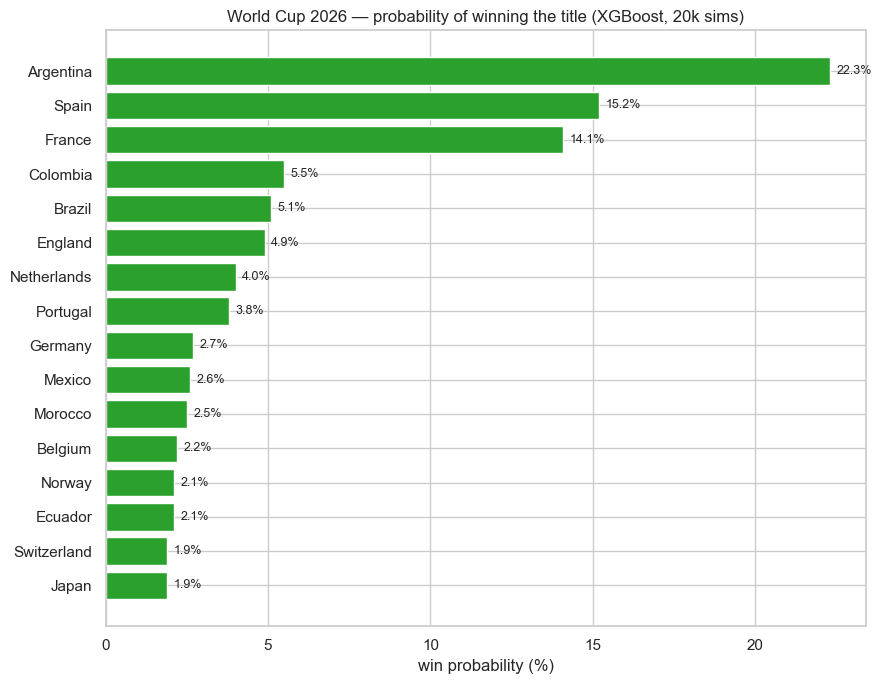

In [8]:
top16 = sim.head(16)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top16["team"][::-1], top16["win_cup"][::-1], color="#2ca02c")
ax.set_title("World Cup 2026 — probability of winning the title (XGBoost, 20k sims)")
ax.set_xlabel("win probability (%)")
for i, v in enumerate(top16["win_cup"][::-1]):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()

**Reading it:** **Argentina** is the clear favourite (~21%), then **Spain** and
**France** — which lines up with the real bookmaker market for 2026. Each row of the
table above also shows the team's chance to *reach* every round, not just to win.

### Round of 32 — the exact matchups

These 16 ties are **already set** (both teams known), so we can show each one
head-to-head: the model's probability for **each team to win that match and advance**.
For the later rounds we don't yet know the opponents, so those stay as the
round-by-round Monte Carlo above.

,match,team_A,win_A_%,win_B_%,team_B,favorite
0,M73,South Africa,26.8,73.2,Canada,Canada
1,M74,Germany,60.1,39.9,Paraguay,Germany
2,M75,Netherlands,53.8,46.2,Morocco,Netherlands
3,M76,Brazil,59.1,40.9,Japan,Brazil
4,M77,France,82.6,17.4,Sweden,France
5,M78,Ivory Coast,36.1,63.9,Norway,Norway
6,M79,Mexico,51.8,48.2,Ecuador,Mexico
7,M80,England,73.4,26.6,DR Congo,England
8,M81,United States,71.0,29.0,Bosnia and Herzegovina,United States
9,M82,Belgium,52.1,47.9,Senegal,Belgium


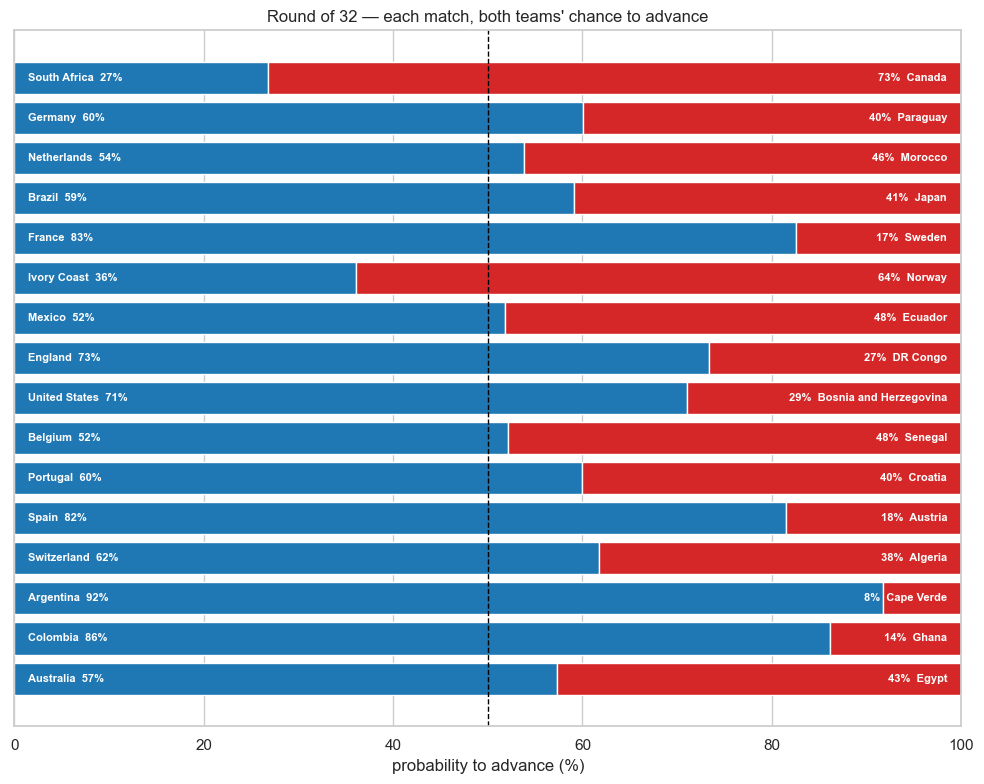

In [9]:
r32 = W.round32_probabilities(adv)
display(r32[["match", "team_A", "win_A_%", "win_B_%", "team_B", "favorite"]])

fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(r32))
ax.barh(y, r32["win_A_%"], color="#1f77b4")
ax.barh(y, r32["win_B_%"], left=r32["win_A_%"], color="#d62728")
for i, row in r32.iterrows():
    ax.text(1.5, i, f"{row.team_A}  {row['win_A_%']:.0f}%", va="center", ha="left",
            color="white", fontsize=8, fontweight="bold")
    ax.text(98.5, i, f"{row['win_B_%']:.0f}%  {row.team_B}", va="center", ha="right",
            color="white", fontsize=8, fontweight="bold")
ax.axvline(50, color="black", lw=1, ls="--")
ax.set_yticks([]); ax.set_xlim(0, 100); ax.set_xlabel("probability to advance (%)")
ax.set_title("Round of 32 — each match, both teams' chance to advance")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 8. Is the forecast robust? (model agreement)

A forecast you can trust shouldn't swing wildly with the choice of model. Here are the
title odds from all three.

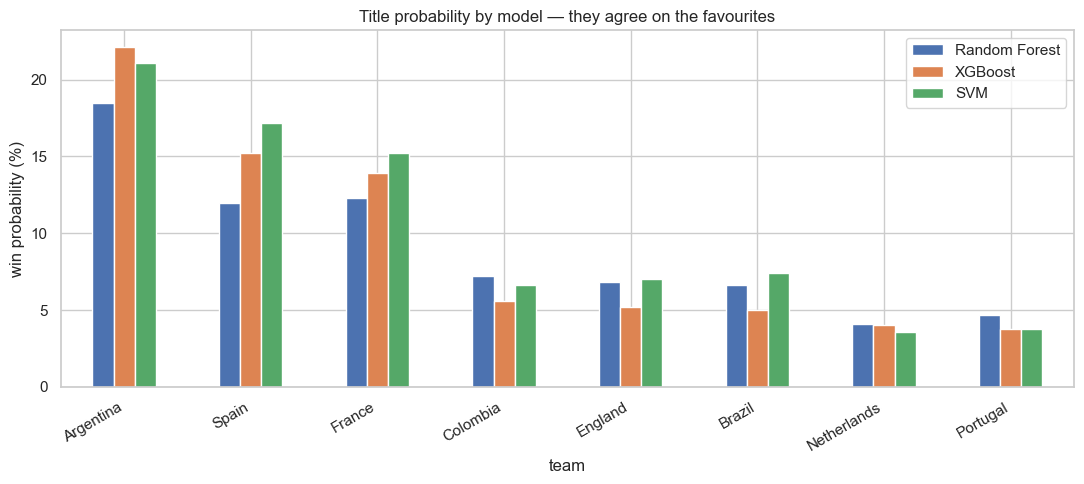

,Random Forest,XGBoost,SVM
team,,,
Argentina,18.5,22.1,21.1
Spain,12.0,15.2,17.2
France,12.3,13.9,15.2
Colombia,7.2,5.6,6.6
England,6.8,5.2,7.0
Brazil,6.6,5.0,7.4
Netherlands,4.1,4.0,3.6
Portugal,4.7,3.8,3.8


In [10]:
champs = {}
for name, mdl in models_full.items():
    a = W.advance_matrix(mdl, pipe_full, le_full, W.KO_TEAMS, ratings, form)
    champs[name] = W.simulate_knockout(a, n_sims=10000).set_index("team")["win_cup"]
comp = pd.DataFrame(champs).sort_values("XGBoost", ascending=False).head(8)

comp.plot(kind="bar", figsize=(11, 5))
plt.title("Title probability by model — they agree on the favourites")
plt.ylabel("win probability (%)"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()
comp.round(1)

**Reading it:** all three models crown Argentina, then Spain and France, with similar
numbers. The agreement is the point — the forecast reflects the data, not a quirk of
one algorithm.

## 9. Conclusion — Application B

Using the **same three models** as the league project, we:

1. built **Elo** team strength from 150 years of internationals (FIFA ranking wasn't
   enough — it stops in 2024),
2. **validated** on the real 2026 group stage (≈60% match accuracy, **25–26/32**
   advancers correct),
3. and ran a **Monte Carlo** of the knockout bracket → **Argentina ~21%** to win, then
   Spain and France, robust across all three models.

This is the second half of the one-sentence thesis: *we built RF / XGBoost / SVM to
predict football, then used the same methodology for two real decisions — beating a
betting market (Application A) and forecasting a live World Cup (Application B).*
